# Notebook for analysis of Ablation Study

Similar in fuction to the model analysis notebook.
However this notebook will be used to compare the performance across ablation steps to see local and global effects of image operations like motion blur

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set a clean visual style
sns.set_theme(style="whitegrid")

# UPDATED: Now including all four of your specific evaluation metrics
METRICS = ['CIDEr_Score', 'SPICE_Score', 'METEOR_Score', 'CLIPScore_Score']

In [11]:
# --- Inputs ---
# 1. What are we testing? This will label your X-axis on the graphs
ABLATION_NAME = 'Blur Kernel Size' # Change this to 'Noise Level' when doing noise

MODEL_NAME = "Gemma4"

# 2. Map your numeric ablation values to their file paths (0 = Standard/Control)
ABLATION_FILES = {
    0: "../results/metrics-results/control-set/gemma-4b_BaseSet_20260426_140144.csv",
    # 31: "../results/metrics-results/ablation-set/gemma4_blur31_20260426_140844.csv"
    # # Example for noise: 
    80: "../results/metrics-results/ablation-set/gemma-4b_noise80_20260426_184251.csv"
}

dataframes = []

for ablation_val, file_path in ABLATION_FILES.items():
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        
        # Tag with the generic numeric ablation level
        df['Ablation_Level'] = ablation_val
        df['Model'] = MODEL_NAME
        
        dataframes.append(df)
        print(f"Loaded: {ABLATION_NAME} {ablation_val} ({len(df)} rows)")
    else:
        print(f"Warning: Could not find file for {ABLATION_NAME} {ablation_val} at {file_path}")

if dataframes:
    df_all = pd.concat(dataframes, ignore_index=True)
    print("\nCombined Data Preview:")
    display(df_all.head())
else:
    print("No data was loaded. Please check your file paths.")

Loaded: Blur Kernel Size 0 (5000 rows)
Loaded: Blur Kernel Size 80 (5000 rows)

Combined Data Preview:


,Image_ID,Generated_Caption,CIDEr_Score,SPICE_Score,METEOR_Score,CLIPScore_Score,Ablation_Level,Model
0,000000456865.jpg,A China Eastern airplane taxis on an airfield ...,0.2306,0.0000,0.3757,0.2734,0,Gemma4
1,000000435003.jpg,A modern office workspace features computers a...,0.1578,0.2667,0.3507,0.3083,0,Gemma4
2,000000084431.jpg,A slice of ham and cheese pizza on a plate.,1.4739,0.1176,0.7390,0.3049,0,Gemma4
3,000000402346.jpg,A white and orange lily sits near tomatoes and...,0.5471,0.2500,0.3676,0.3333,0,Gemma4
4,000000294695.jpg,Colorful kites fly over a sandy beach with peo...,0.3045,0.1250,0.4092,0.3352,0,Gemma4


In [12]:
# Calculate Mean, Median, Variance, and Skewness grouping by the new generic column
summary_stats = df_all.groupby(['Model', 'Ablation_Level'])[METRICS].agg(['mean', 'median', 'var', 'skew'])

# Flatten the multi-level column names (e.g., 'CIDEr_Score_mean')
summary_stats.columns = ['_'.join(col).strip() for col in summary_stats.columns.values]
summary_stats = summary_stats.reset_index()

print("Summary Statistics:")
display(summary_stats)

Summary Statistics:


,Model,Ablation_Level,CIDEr_Score_mean,CIDEr_Score_median,CIDEr_Score_var,CIDEr_Score_skew,SPICE_Score_mean,SPICE_Score_median,SPICE_Score_var,SPICE_Score_skew,METEOR_Score_mean,METEOR_Score_median,METEOR_Score_var,METEOR_Score_skew,CLIPScore_Score_mean,CLIPScore_Score_median,CLIPScore_Score_var,CLIPScore_Score_skew
0,Gemma4,0,0.424196,0.32535,0.157292,2.108102,0.161644,0.1481,0.009718,0.818940,0.373100,0.3647,0.027743,0.481484,0.317537,0.3169,0.001018,0.007632
1,Gemma4,80,0.295554,0.19275,0.114272,2.016767,0.116592,0.1053,0.008543,0.770847,0.320751,0.3125,0.026220,0.570582,0.286102,0.2908,0.002050,-0.495370


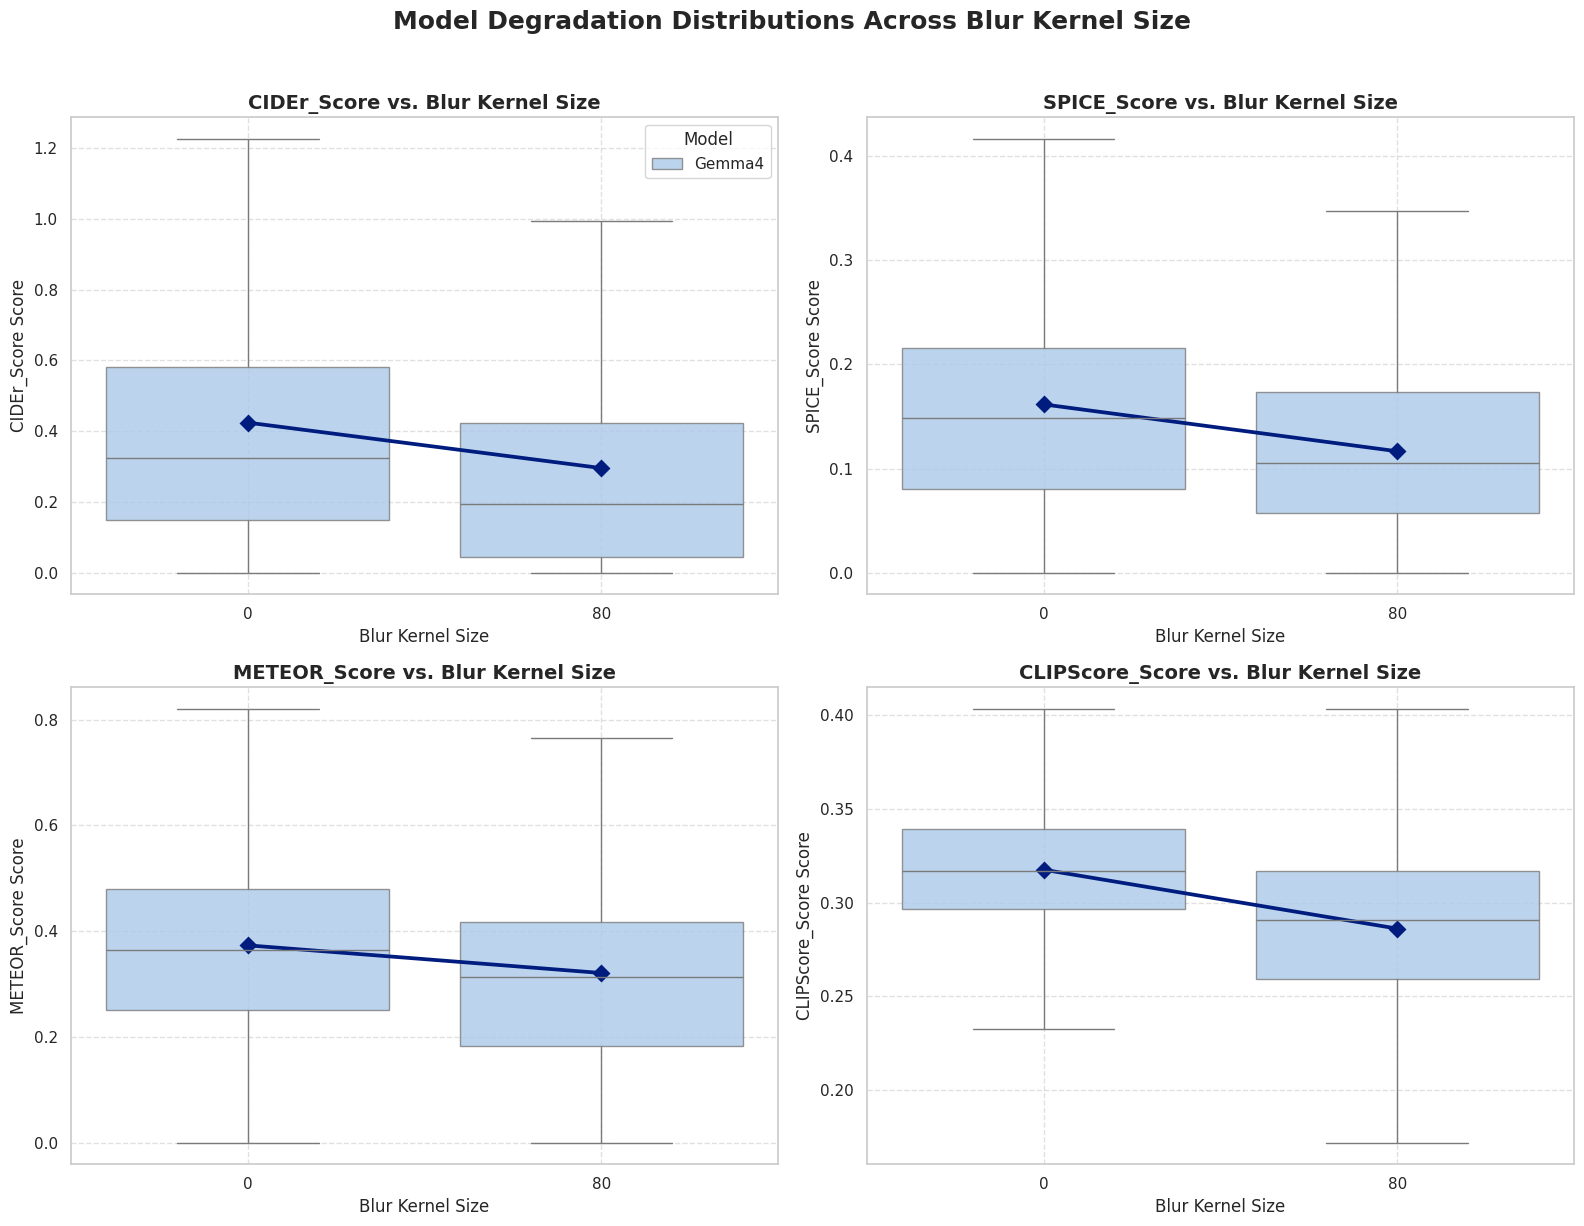

In [13]:
def plot_paper_ready_distributions(df_raw, metrics, x_axis_name):
    """
    Plots a 2x2 grid of boxplots with an overlaid trendline for the mean.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    # THE FIX: Only 'dodge' (space out points) if we have more than 1 model
    num_models = df_raw['Model'].nunique()
    dodge_val = 0.4 if num_models > 1 else False

    for i, metric in enumerate(metrics):
        ax = axes[i]
        
        # 1. The Boxplot
        sns.boxplot(
            data=df_raw, 
            x='Ablation_Level', 
            y=metric, 
            hue='Model',
            ax=ax,
            palette="pastel",
            boxprops=dict(alpha=0.8),
            showfliers=False
        )
        
        # 2. The Trendline
        sns.pointplot(
            data=df_raw, 
            x='Ablation_Level', 
            y=metric, 
            hue='Model',
            ax=ax,
            dodge=dodge_val, # Uses our new dynamic variable
            markers='D',
            linestyles='-', 
            errorbar=None,
            palette="dark",
            legend=False
        )
        
        # Formatting
        ax.set_title(f'{metric} vs. {x_axis_name}', fontsize=14, fontweight='bold')
        ax.set_ylabel(f'{metric} Score', fontsize=12)
        ax.set_xlabel(x_axis_name, fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Clean up legends
        if i == 0:
            handles, labels = ax.get_legend_handles_labels()
            # Only take the unique models for the legend to prevent duplicates
            ax.legend(handles[:num_models], labels[:num_models], title='Model', loc='best')
        else:
            if ax.get_legend() is not None:
                ax.get_legend().remove()

    plt.suptitle(f'Model Degradation Distributions Across {x_axis_name}', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# --- Run the Plot ---
plot_paper_ready_distributions(df_all, METRICS, x_axis_name=ABLATION_NAME)

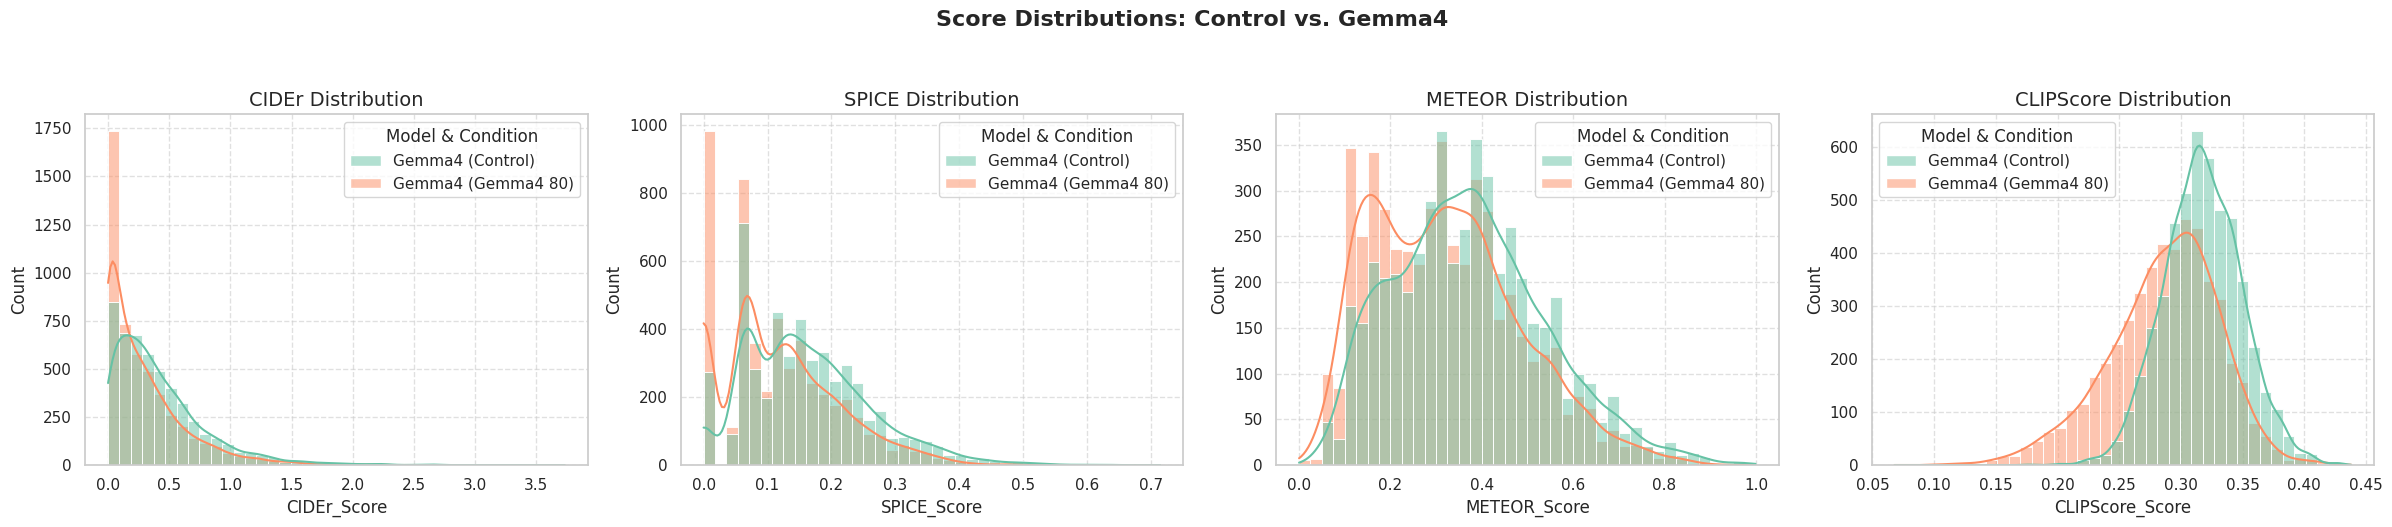

In [14]:
def plot_ablation_distributions(df_raw, metrics, ablation_name):
    """
    Plots a 1x4 grid of histograms with KDE overlays to compare the 
    distributions of the control set vs. the ablation set, including the Model name.
    """
    # Create a 1x4 grid to match the reference style
    fig, axes = plt.subplots(1, 4, figsize=(24, 5))
    
    # Create a temporary column for a cleaner legend that includes the Model
    df_plot = df_raw.copy()
    df_plot['Condition'] = df_plot.apply(
        lambda row: f"{row['Model']} (Control)" if float(row['Ablation_Level']) == 0 
                    else f"{row['Model']} ({ablation_name} {row['Ablation_Level']})", 
        axis=1
    )

    for i, metric in enumerate(metrics):
        ax = axes[i]
        
        # Plot the distribution with KDE
        sns.histplot(
            data=df_plot,
            x=metric,
            hue='Condition',
            kde=True,
            ax=ax,
            palette="Set2",
            alpha=0.5,
            bins=40,
            edgecolor=None
        )
        
        # Clean up the metric name for the title (e.g., 'CIDEr_Score' -> 'CIDEr')
        metric_name = metric.replace('_Score', '')
        ax.set_title(f'{metric_name} Distribution', fontsize=14)
        ax.set_xlabel(metric, fontsize=12)
        ax.set_ylabel('Count', fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Ensure legend title is clean
        if ax.get_legend() is not None:
            ax.get_legend().set_title('Model & Condition')

    plt.suptitle(f'Score Distributions: Control vs. {ablation_name}', fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

# --- Run the Plot ---
plot_ablation_distributions(df_all, METRICS, MODEL_NAME)